In [4]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from scipy import stats

1. POBRANIE DANYCH (Predict Students' Dropout and Academic Success)

https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [5]:
dataset = fetch_ucirepo(id=697)
df = dataset.data.features
df['Target'] = dataset.data.targets

do klasyfikacji binarnej potrzebujemy tylko: 0 - Dropout i 1 - Graduate. Enrolled zostaje odrzucone

In [6]:
df = df[df['Target'].isin(['Dropout', 'Graduate'])].copy()
df['Target'] = df['Target'].map({'Dropout': 0, 'Graduate': 1})

2. USUWANIE DUPLIKATÓW I BRAKÓW DANYCH

In [7]:
print(f"Rozmiar przed usunięciem duplikatów: {df.shape}")
df = df.drop_duplicates()
print(f"Rozmiar po usunięciu duplikatów: {df.shape}")
df = df.dropna()

Rozmiar przed usunięciem duplikatów: (3630, 37)
Rozmiar po usunięciu duplikatów: (3630, 37)


 3. KODOWANIE ZMIENNYCH KATEGORYCZNYCH

In [8]:
categorical_features = ['Marital Status', 'Application mode', 'Application order', 'Course',
                        'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
                        'Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation',
                        'Father\'s occupation', 'Displaced', 'Educational special needs',
                        'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
#zamiana nazw kolumn na string żeby get_dumies działało poprawnie
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype(str)

df = pd.get_dummies(df, drop_first=True)

4. DETEKCJA I USUWANIE WARTOŚCI ODSTAJĄCYCH (OUTLIERS) ZA POMOCĄ Z-SCORE

In [9]:
numerical_cols = ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment']

# Obliczamy Z-score i usuwamy wiersze, gdzie wartość odstaje o więcej niż 3 odchylenia standardowe
z_scores = np.abs(stats.zscore(df[numerical_cols]))
df = df[(z_scores < 3).all(axis=1)]
print(f"Rozmiar po usunięciu wartości odstających (Z-score): {df.shape}")

Rozmiar po usunięciu wartości odstających (Z-score): (3511, 235)


5. PODZIAŁ NA CECHY (X) I ZMIENNĄ DOCELOWĄ (Y)

In [10]:
X = df.drop('Target', axis=1)
y = df['Target']

6. BALANSOWANIE ZBIORU (SMOTE)

In [11]:
print(f"\nRozkład klas przed SMOTE:\n{y.value_counts()}")
smote = SMOTE(random_state=1)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"Rozkład klas po SMOTE:\n{y_resampled.value_counts()}")


Rozkład klas przed SMOTE:
Target
1    2157
0    1354
Name: count, dtype: int64
Rozkład klas po SMOTE:
Target
0    2157
1    2157
Name: count, dtype: int64


/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


7. PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY (80/20)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=1)

8. SKALOWANIE / NORMALIZACJA

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

9. MODEL BENCHMARKOWY: REGRESJA LOGISTYCZNA

In [14]:
benchmark_model = LogisticRegression(max_iter=1000, random_state=1)
benchmark_model.fit(X_train_scaled, y_train)

y_pred = benchmark_model.predict(X_test_scaled)

/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmu

In [15]:
acc = accuracy_score(y_test, y_pred)
print(f"Dokładność (Accuracy) modelu bazowego: {acc:.4f}")

Dokładność (Accuracy) modelu bazowego: 0.9270


# ==========================================
# LAB 2 - OCENA SKUTECZNOŚCI I OPTYMALIZACJA
# ==========================================

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

Matplotlib is building the font cache; this may take a moment.


Metryki dla modelu z lab 1

In [17]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9270
Precision: 0.9055
Recall:    0.9470
F1-score:  0.9258


macierz pomyłek

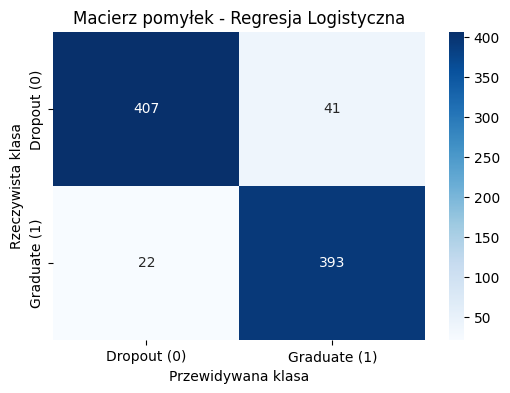

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Dropout (0)", "Graduate (1)"], yticklabels=["Dropout (0)", "Graduate (1)"])
plt.xlabel("Przewidywana klasa")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek - Regresja Logistyczna")
plt.show()

OPTYMALIZACJA MODELU RANDOM FOREST


In [19]:
rf = RandomForestClassifier(random_state=42)

# Definiujemy siatkę parametrów do przeszukania
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Randomized Search
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

best_rf = random_search.best_estimator_
print(f"Najlepsze hiperparametry: {random_search.best_params_}")

y_pred_rf = best_rf.predict(X_test_scaled)
print(f"Accuracy (Zoptymalizowany RF): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-score (Zoptymalizowany RF): {f1_score(y_test, y_pred_rf):.4f}")

Najlepsze hiperparametry: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 30}
Accuracy (Zoptymalizowany RF): 0.9282
F1-score (Zoptymalizowany RF): 0.9267


ANALIZA ISTOTNOŚCI CECH Random Forest

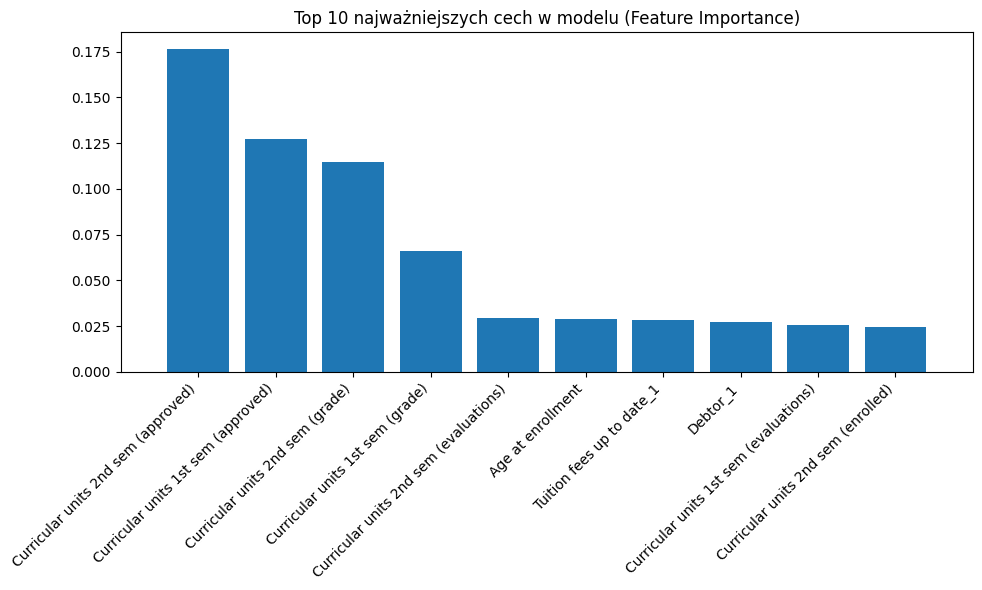

In [20]:
importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 10 najważniejszych cech w modelu (Feature Importance)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.xlim([-1, 10])
plt.tight_layout()
plt.show()
